* ## New York City Taxi Ride Duration - Data Cleaning

* **By Abdallah Hashem**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# to  ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
df1 = pd.read_csv(r"C:\Users\Abdullah\PyCharmMiscProject\ML\Project_trip\Data\split\train.csv")
df2 = pd.read_csv(r"C:\Users\Abdullah\PyCharmMiscProject\ML\Project_trip\Data\split\val.csv")
df = pd.concat([df1, df2])

df.reset_index(drop=True, inplace=True)

In [3]:
df1.shape , df2.shape , df.shape

((1000000, 10), (229319, 10), (1229319, 10))

In [4]:
df.head(5)

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1,id3485529,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827
2,id1816614,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614
3,id1050851,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867
4,id0140657,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967


In [5]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration'],
      dtype='object')

**How the dataset look like**
* We have 10 feature and 1 target

**id** . A unique identifier for each trip. It serves as a primary key to distinguish one trip from another.

**vendor_id**.A code indicating the provider associated with the trip record. This could represent different taxi companies or service providers.

**pickup_datetime**.he date and time when the meter was engaged, marking the start of the trip.

**passenger_count**.The number of passengers in the vehicle. It is a driver-entered value, indicating how many individuals were in the taxi during the trip.

**pickup_longitud**. The longitude coordinate where the meter was engaged, i.e., the pickup location.
engaged, i.e., the pickup location.

**pickup_latitude**.The latitude coordinate where the meter was engaged, i.e., the pickup location.
engaged, i.e., the pickup location.

**dropoff_longitude**.The longitude coordinate where the meter was disengaged, i.e., the dropoff location.

**dropoff_latitude**.The latitude coordinate where the meter was disengaged, i.e., the dropoff location.

**store_and_fwd_flag**.This flag indicates whether the data was sent to the vendor in real-time ("N") or whether it was stored in the vehicle's memory and sent later when a connection was available ("Y").

**trip_duration**.The duration of the trip in seconds, i.e., the time between the pickup and dropoff.





### Summry Statistics

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,1229319.0,1.534912,0.498780,1.000000,1.000000,2.000000,2.000000,2.000000e+00
passenger_count,1229319.0,1.664531,1.314509,0.000000,1.000000,1.000000,2.000000,8.000000e+00
pickup_longitude,1229319.0,-73.973446,0.061780,-121.933342,-73.991852,-73.981728,-73.967346,-6.133553e+01
pickup_latitude,1229319.0,40.750928,0.033545,34.359695,40.737370,40.754108,40.768360,5.188108e+01
dropoff_longitude,1229319.0,-73.973395,0.061641,-121.933304,-73.991325,-73.979759,-73.963028,-6.133553e+01
dropoff_latitude,1229319.0,40.751816,0.036341,32.181141,40.735901,40.754532,40.769821,4.392103e+01
trip_duration,1229319.0,959.691748,5263.573404,1.000000,397.000000,662.000000,1075.000000,3.526282e+06


* We have 2 vendor (taxi companies) , there is any differint in speed ??
* passenger_count we have two challenging
*
        1. Min passenger_count is 0 (No passenger this it outlier )
       2. Max passenger_count is 8 car can be SUV or not but it is large number at any way

* trip_duration Max trip_duration is 3.526282e+06 sec this is 40 days definitely outlier

### check duplicates

In [7]:
num_duplicates = df.duplicated().sum()
print(f'number of duplicates : {num_duplicates}')
print(f'number of NaN values : {df.isna().sum().sum()}')
print(f'number of null values : {df.isnull().sum().sum()}')

# actually drop duplicates if any exist
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)


number of duplicates : 0
number of NaN values : 0
number of null values : 0


### get feature details

In [8]:
def get_feature_details(feature_name:str):
    print (df[feature_name].value_counts() , end="\n\n")
    print (df[feature_name].describe() , end="\n\n")

In [9]:
get_feature_details('vendor_id')

vendor_id
2    657578
1    571741
Name: count, dtype: int64

count    1.229319e+06
mean     1.534912e+00
std      4.987798e-01
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      2.000000e+00
max      2.000000e+00
Name: vendor_id, dtype: float64



In [10]:
get_feature_details('pickup_datetime')

pickup_datetime
2016-05-07 13:18:07    5
2016-04-05 18:55:21    5
2016-01-12 18:48:44    5
2016-03-31 08:02:33    4
2016-02-24 12:04:42    4
                      ..
2016-02-21 02:02:26    1
2016-04-18 20:45:20    1
2016-02-14 08:32:03    1
2016-05-16 16:24:41    1
2016-02-08 19:38:00    1
Name: count, Length: 1173138, dtype: int64

count                 1229319
unique                1173138
top       2016-05-07 13:18:07
freq                        5
Name: pickup_datetime, dtype: object



In [11]:
get_feature_details('passenger_count')

passenger_count
1    871202
2    177073
5     65797
3     50470
6     40790
4     23932
0        51
7         3
8         1
Name: count, dtype: int64

count    1.229319e+06
mean     1.664531e+00
std      1.314509e+00
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      8.000000e+00
Name: passenger_count, dtype: float64



### Passenger Count Outliers
* Removing trips with 0 passengers (invalid/sensor error)
* Keeping the realistic range [1, 6] passengers (7 and 8 are extremely rare and likely data entry errors for a standard taxi)


In [12]:
print(f"Rows before passenger_count cleaning: {df.shape[0]}")
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)].copy()
print(f"Rows after passenger_count cleaning: {df.shape[0]}")


Rows before passenger_count cleaning: 1229319
Rows after passenger_count cleaning: 1229264


* We hyave 51 trip with 0 passenger it is outlier ( can be error  in system )
* range of people took a taxi is [1,8] 

In [13]:
get_feature_details('pickup_longitude')

pickup_longitude
-73.982140    512
-73.982201    511
-73.982101    510
-73.982224    499
-73.982117    487
             ... 
-73.915649      1
-73.880127      1
-73.906624      1
-73.884155      1
-73.724243      1
Name: count, Length: 22203, dtype: int64

count    1.229264e+06
mean    -7.397345e+01
std      6.177920e-02
min     -1.219333e+02
25%     -7.399185e+01
50%     -7.398173e+01
75%     -7.396735e+01
max     -6.133553e+01
Name: pickup_longitude, dtype: float64



In [14]:
get_feature_details('pickup_latitude')

pickup_latitude
40.774090    362
40.774101    344
40.774120    341
40.774078    333
40.774109    331
            ... 
40.836491      1
40.820110      1
40.682068      1
40.674248      1
40.695606      1
Name: count, Length: 43805, dtype: int64

count    1.229264e+06
mean     4.075093e+01
std      3.354371e-02
min      3.435970e+01
25%      4.073737e+01
50%      4.075411e+01
75%      4.076836e+01
max      5.188108e+01
Name: pickup_latitude, dtype: float64



In [15]:
get_feature_details('dropoff_longitude')

dropoff_longitude
-73.982330    378
-73.982094    377
-73.982246    368
-73.982117    362
-73.982201    359
             ... 
-73.862518      1
-73.778877      1
-74.152420      1
-73.867424      1
-73.720047      1
Name: count, Length: 32215, dtype: int64

count    1.229264e+06
mean    -7.397340e+01
std      6.163952e-02
min     -1.219333e+02
25%     -7.399133e+01
50%     -7.397976e+01
75%     -7.396303e+01
max     -6.133553e+01
Name: dropoff_longitude, dtype: float64



In [16]:
get_feature_details('dropoff_latitude')

dropoff_latitude
40.774311    225
40.774330    224
40.750118    222
40.774319    217
40.750198    215
            ... 
40.835400      1
40.877274      1
40.672573      1
40.672325      1
40.668873      1
Name: count, Length: 60232, dtype: int64

count    1.229264e+06
mean     4.075182e+01
std      3.634007e-02
min      3.218114e+01
25%      4.073590e+01
50%      4.075453e+01
75%      4.076982e+01
max      4.392103e+01
Name: dropoff_latitude, dtype: float64



In [17]:
get_feature_details('store_and_fwd_flag')

store_and_fwd_flag
N    1222449
Y       6815
Name: count, dtype: int64

count     1229264
unique          2
top             N
freq      1222449
Name: store_and_fwd_flag, dtype: object



In [18]:
get_feature_details('trip_duration')

trip_duration
368      1357
417      1352
348      1349
424      1343
367      1340
         ... 
84153       1
83214       1
5006        1
5942        1
86021       1
Name: count, Length: 7146, dtype: int64

count    1.229264e+06
mean     9.596529e+02
std      5.263130e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64



In [19]:
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1,id3485529,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827
2,id1816614,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614
3,id1050851,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867
4,id0140657,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967


* The time format not help us to goog information about different time
* I will try to fix it by split it in to new

## Feature Engineering 

In [20]:
df['trip_duration'].describe()

count    1.229264e+06
mean     9.596529e+02
std      5.263130e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

In [21]:
trip_by_seconds = df['trip_duration'].copy()
trip_by_minutes = trip_by_seconds / 60
df['trip_by_minutes'] = trip_by_minutes

In [22]:
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_by_minutes
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040,17.333333
1,id3485529,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827,13.783333
2,id1816614,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614,10.233333
3,id1050851,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867,14.450000
4,id0140657,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967,82.783333


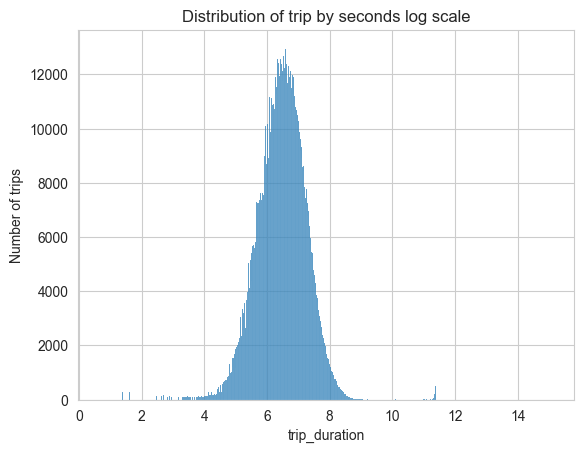

In [23]:
# Log scale to visualise better because big scale
df['trip_by_seconds_Log_Transformed'] = np.log1p(df['trip_duration'].values)
fig = sns.histplot(df['trip_by_seconds_Log_Transformed'], label='trip_duration')
plt.title('Distribution of trip by seconds log scale')
plt.xlabel('trip_duration')
plt.ylabel('Number of trips')
plt.show()


* Between 10 and 12 there is some values can be outlier

In [24]:
df.drop(columns = ['id'] , inplace=True , axis=1)

In [25]:
short_trip = df[df['trip_duration'] < 60]
len(short_trip)

7197

In [26]:
tall_trip = df[df['trip_duration'] > 7200 ]
len(tall_trip)

1921

##  Handling Outliers & Target Variable Transformation

In this phase, we clean our target variable (`trip_duration`) by removing extreme outliers and transforming its distribution. This step is crucial for helping our regression models learn patterns more effectively.

### Key Processing Steps:
* **Outlier Removal:** We filtered out unrealistic trips that lasted less than 1 minute (60 seconds) or more than 2 hours (7200 seconds). This successfully cleaned the **7236 extremely short** and **1922 extremely long** anomalous trips.
* **Log Transformation:** To address the heavy **Right Skewness** of the trip durations, we applied a logarithmic scale using `np.log1p`. This transformed the highly skewed distribution into a symmetrical, bell-shaped **Normal Distribution**.

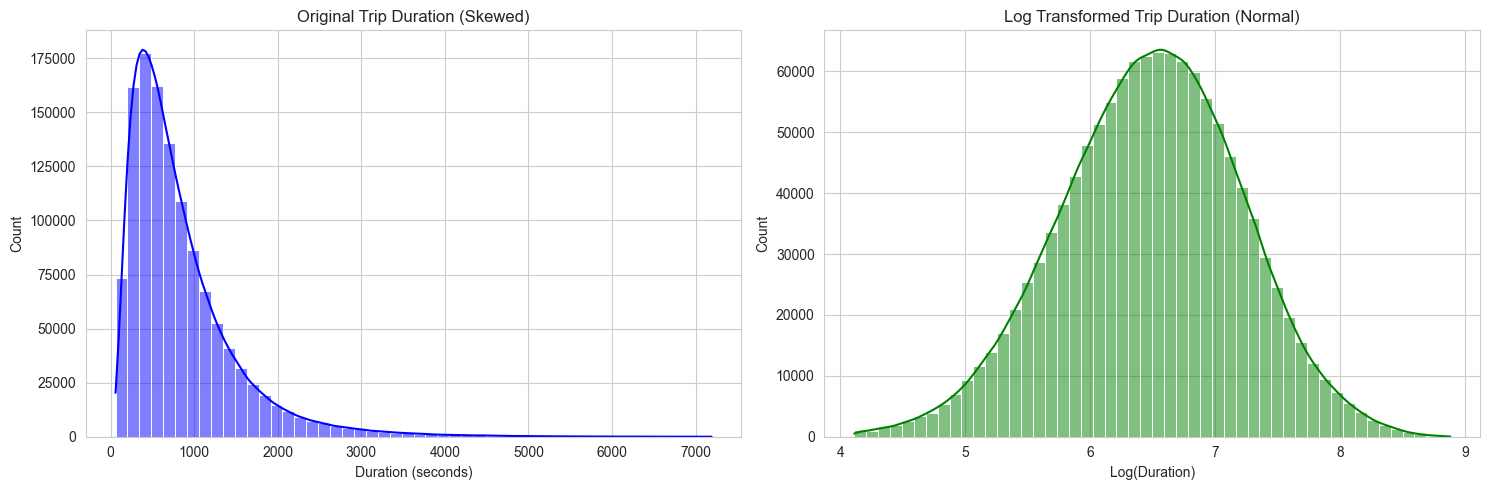

Data shape after removing duration outliers: (1220146, 11)


In [27]:
# 1.remove outlier 7236 and 1922
df= df[(df['trip_duration'] >= 60) & (df['trip_duration'] <= 7200)].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# with Skewness
sns.histplot(df['trip_duration'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Original Trip Duration (Skewed)')
axes[0].set_xlabel('Duration (seconds)')

# normal distrbution
sns.histplot(df['trip_by_seconds_Log_Transformed'], bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Log Transformed Trip Duration (Normal)')
axes[1].set_xlabel('Log(Duration)')

plt.tight_layout()
plt.show()

print(f"Data shape after removing duration outliers: {df.shape}")



### Geographical Data 

In [28]:
def haversine_distance(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

df['distance_km'] = haversine_distance(
    df['pickup_longitude'], df['pickup_latitude'],
    df['dropoff_longitude'], df['dropoff_latitude']
)

In [29]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_by_minutes,trip_by_seconds_Log_Transformed,distance_km
0,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040,17.333333,6.947937,2.761315
1,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827,13.783333,6.719013,1.957948
2,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614,10.233333,6.421622,1.403890
3,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867,14.450000,6.766192,1.977417
4,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967,82.783333,8.510773,20.824662


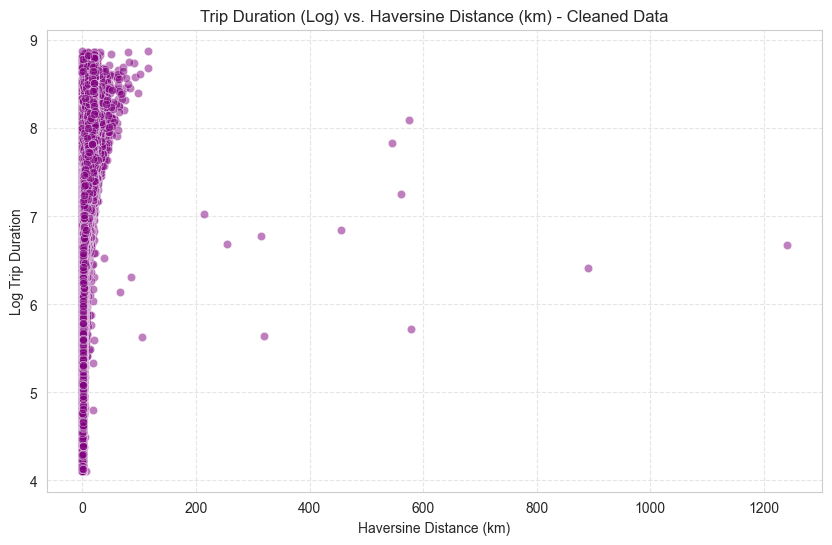

In [30]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance_km', y='trip_by_seconds_Log_Transformed', alpha=0.5, color='purple')
plt.title('Trip Duration (Log) vs. Haversine Distance (km) - Cleaned Data')
plt.xlabel('Haversine Distance (km)')
plt.ylabel('Log Trip Duration')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [31]:
df.columns

Index(['vendor_id', 'pickup_datetime', 'passenger_count', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'store_and_fwd_flag', 'trip_duration', 'trip_by_minutes',
       'trip_by_seconds_Log_Transformed', 'distance_km'],
      dtype='object')

In [32]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [33]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_by_minutes,trip_by_seconds_Log_Transformed,distance_km
0,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040,17.333333,6.947937,2.761315
1,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827,13.783333,6.719013,1.957948
2,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614,10.233333,6.421622,1.403890
3,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867,14.450000,6.766192,1.977417
4,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967,82.783333,8.510773,20.824662


In [34]:
# Now from every date/time we can get new information like Month/day/ Morning or afternoon or night / season for each trip
df_date_time = pd.DataFrame()

df_date_time["pickup_month"] = df["pickup_datetime"].dt.month
df_date_time["pickup_day"] = df["pickup_datetime"].dt.day
df_date_time["pickup_hour"] = df["pickup_datetime"].dt.hour
df_date_time["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek
df_date_time["pickup_quarter"] = df["pickup_datetime"].dt.quarter
df_date_time["trip_duration"] = df['trip_by_seconds_Log_Transformed']

# --- Season ---
bins = [0, 2, 5, 8, 11, 12]  # start/end months of each season
labels = ['Winter', 'Spring', 'Summer', 'Autumn', 'Winter']
df_date_time["pickup_Season"] = pd.cut(
    df_date_time["pickup_month"], bins=bins, labels=labels, ordered=False
)

# --- Time of day period ---
def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df_date_time["time_period"] = df_date_time["pickup_hour"].apply(get_time_period)

# --- Weekend flag (bonus feature) ---
df_date_time["is_weekend"] = df_date_time["pickup_dayofweek"].isin([5, 6]).astype(int)

df_date_time.head()


,pickup_month,pickup_day,pickup_hour,pickup_dayofweek,pickup_quarter,trip_duration,pickup_Season,time_period,is_weekend
0,6,8,7,2,2,6.947937,Summer,Morning,0
1,4,3,12,6,2,6.719013,Spring,Afternoon,1
2,6,5,2,6,2,6.421622,Summer,Night,1
3,5,5,17,3,2,6.766192,Spring,Evening,0
4,5,12,17,3,2,8.510773,Spring,Evening,0


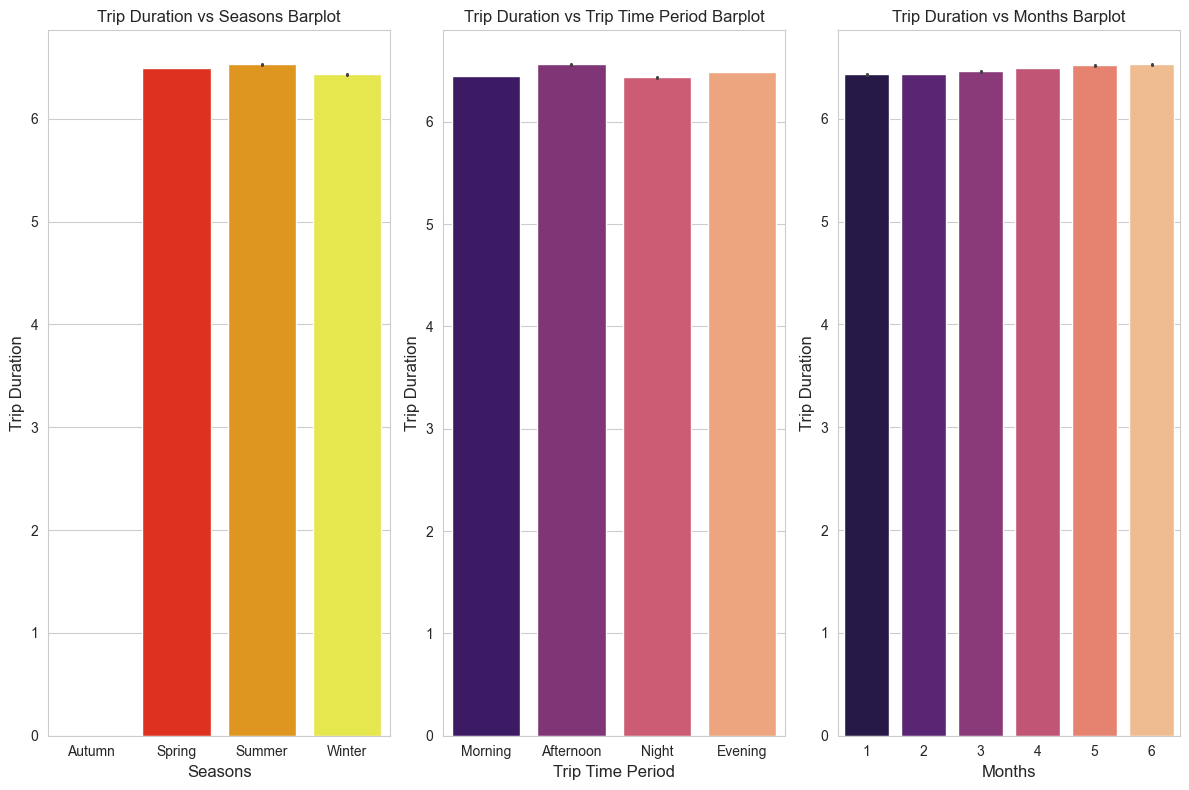

In [35]:
# Create the figure with GridSpec and specify the size
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 8))

# Subplot 1: Bar Plot for Seasons
sns.barplot(data=df_date_time, x="pickup_Season", y=df['trip_by_seconds_Log_Transformed'], palette='hot', ax=ax1)
ax1.set_title('Trip Duration vs Seasons Barplot')
ax1.set_xlabel("Seasons", fontsize=12)
ax1.set_ylabel("Trip Duration", fontsize=12)

# Subplot 2: Bar Plot for time period
sns.barplot(data=df_date_time, x="time_period", y=df['trip_by_seconds_Log_Transformed'], palette='magma', ax=ax2)
ax2.set_title('Trip Duration vs Trip Time Period Barplot')
ax2.set_xlabel("Trip Time Period", fontsize=12)
ax2.set_ylabel("Trip Duration", fontsize=12)

# Subplot 3: Bar Plot for months
sns.barplot(data=df_date_time, x="pickup_month", y=df['trip_by_seconds_Log_Transformed'], palette='magma', ax=ax3)
ax3.set_title('Trip Duration vs Months Barplot')
ax3.set_xlabel("Months", fontsize=12)
ax3.set_ylabel("Trip Duration", fontsize=12)

# Adjust layout for better appearance
plt.tight_layout()

# Show the plots
plt.show()

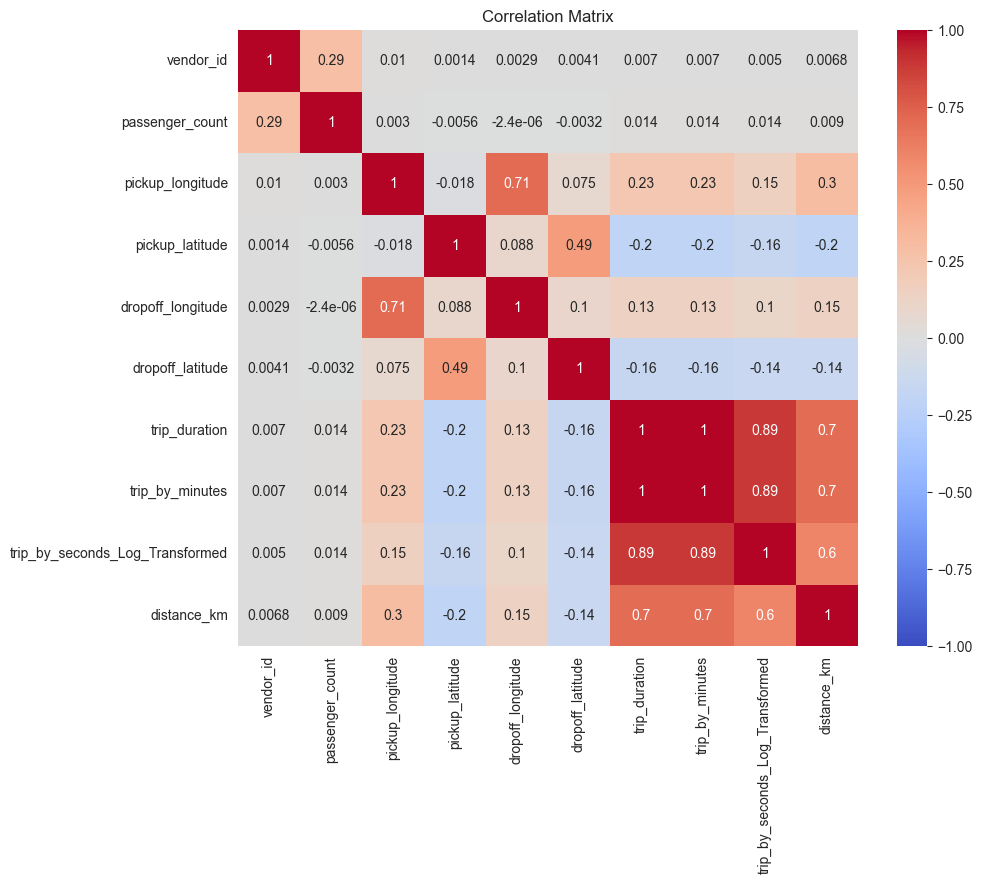

In [36]:
correlation_matrix = df.drop(['pickup_datetime', 'store_and_fwd_flag'], axis=1, inplace=False).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()


In [37]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_by_minutes,trip_by_seconds_Log_Transformed,distance_km
0,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040,17.333333,6.947937,2.761315
1,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827,13.783333,6.719013,1.957948
2,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614,10.233333,6.421622,1.403890
3,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867,14.450000,6.766192,1.977417
4,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967,82.783333,8.510773,20.824662


In [38]:
df = pd.concat([df.reset_index(drop=True), df_date_time.drop(columns=['trip_duration']).reset_index(drop=True)], axis=1)
df.drop(columns=['trip_duration', 'trip_by_minutes', 'pickup_datetime'], inplace=True)

df.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_by_seconds_Log_Transformed,distance_km,pickup_month,pickup_day,pickup_hour,pickup_dayofweek,pickup_quarter,pickup_Season,time_period,is_weekend
0,2,1,-73.985611,40.735943,-73.980331,40.760468,N,6.947937,2.761315,6,8,7,2,2,Summer,Morning,0
1,2,1,-73.978394,40.764351,-73.991623,40.749859,N,6.719013,1.957948,4,3,12,6,2,Spring,Afternoon,1
2,2,5,-73.989059,40.744389,-73.973381,40.748692,N,6.421622,1.403890,6,5,2,6,2,Summer,Night,1
3,2,2,-73.990326,40.731136,-73.991264,40.748917,N,6.766192,1.977417,5,5,17,3,2,Spring,Evening,0
4,1,4,-73.789497,40.646675,-73.987137,40.759232,N,8.510773,20.824662,5,12,17,3,2,Spring,Evening,0


In [40]:
df.shape

(1220146, 17)

In [41]:
df.drop(columns=[
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'pickup_day', 'pickup_quarter'
], inplace=True)

In [42]:
# 1. Binary encoding
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'Y': 1, 'N': 0})

# 2. One-Hot Encoding
df = pd.get_dummies(df, columns=['vendor_id', 'pickup_Season', 'time_period'], drop_first=True)

df.head()

,passenger_count,store_and_fwd_flag,trip_by_seconds_Log_Transformed,distance_km,pickup_month,pickup_hour,pickup_dayofweek,is_weekend,vendor_id_2,pickup_Season_Spring,pickup_Season_Summer,pickup_Season_Winter,time_period_Evening,time_period_Morning,time_period_Night
0,1,0,6.947937,2.761315,6,7,2,0,True,False,True,False,False,True,False
1,1,0,6.719013,1.957948,4,12,6,1,True,True,False,False,False,False,False
2,5,0,6.421622,1.403890,6,2,6,1,True,False,True,False,False,False,True
3,2,0,6.766192,1.977417,5,17,3,0,True,True,False,False,True,False,False
4,4,0,8.510773,20.824662,5,17,3,0,False,True,False,False,True,False,False
